# Brain2Text24 Raw Rate vs Z-Scored Dynamics

This notebook is separate from the SSL training notebooks. It asks a narrower question:

- compute raw per-channel mean firing rate from `brain2text24`
- z-score each channel within session
- measure post-z-score temporal structure per channel
- test whether raw firing rate is associated with those post-z-score measures

This lets us ask whether high-rate channels remain special after amplitude is removed.

In [1]:
from pathlib import Path
import os
import sys
import subprocess
import importlib.util

CACHE_ROOT = Path("/Users/home/thesis/data/cache_v1")
if not CACHE_ROOT.exists():
    raise FileNotFoundError(f"Could not find cache_v1 at {CACHE_ROOT}")

# Keep matplotlib/font caches inside the repo workspace so local notebook kernels
# do not fail on non-writable home-directory cache locations.
NOTEBOOK_DIR = Path.cwd()
MPLCONFIGDIR = NOTEBOOK_DIR / ".mplconfig"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

required_packages = ["matplotlib", "numpy", "pandas"]
missing_packages = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Core notebook packages already available.")

print(f"CACHE_ROOT: {CACHE_ROOT}")

Installing missing packages: matplotlib, numpy, pandas
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 12.3 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 9.4 MB/s eta 0:00:00
CACHE_ROOT: /Users/home/thesis/data/cache_v1



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import json
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET_NAME = "brain2text24"
TASK_FILTER = None
MIN_BINS_PER_CHANNEL = 512
BURST_THRESHOLD = 2.0

dataset_root = CACHE_ROOT / DATASET_NAME
metadata = json.loads((dataset_root / "metadata.json").read_text())

session_to_shards = defaultdict(list)
for shard in metadata["shards"]:
    if TASK_FILTER is not None and shard.get("task_name") not in TASK_FILTER:
        continue
    session_to_shards[shard["session_id"]].append(shard)

session_ids = sorted(session_to_shards)
n_features = metadata["feature_layout"]["n_tx_features"]

print(f"Dataset: {DATASET_NAME}")
print(f"Sessions selected: {len(session_ids)}")
print(f"TX features: {n_features}")
if TASK_FILTER is None:
    print("Task filter: all cached task names")
else:
    print(f"Task filter: {TASK_FILTER}")

pd.DataFrame([
    {
        "session_id": session_id,
        "n_shards": len(shards),
        "task_names": ", ".join(sorted({shard.get("task_name", "") for shard in shards})),
        "total_time_bins": int(sum(shard["total_time_bins"] for shard in shards)),
    }
    for session_id, shards in session_to_shards.items()
]).sort_values(["session_id"]).reset_index(drop=True).head(12)

Matplotlib is building the font cache; this may take a moment.


Dataset: brain2text24
Sessions selected: 28
TX features: 256
Task filter: all cached task names


,session_id,n_shards,task_names,total_time_bins
0,t12.2022.04.21,2,"orofacial, phonemes",89402
1,t12.2022.04.26,1,phonemes,68760
2,t12.2022.04.28,1,sentences,170161
3,t12.2022.05.03,1,fiftyWordSet,102424
4,t12.2022.05.05,1,sentences,192723
5,t12.2022.05.17,1,sentences,172007
6,t12.2022.05.19,1,sentences,90088
7,t12.2022.05.24,1,sentences,162413
8,t12.2022.05.26,1,sentences,155154
9,t12.2022.06.02,1,sentences,157250


In [3]:
def rankdata(x):
    x = np.asarray(x, dtype=np.float64)
    order = np.argsort(x, kind="mergesort")
    ranks = np.empty(len(x), dtype=np.float64)
    sorted_x = x[order]
    i = 0
    while i < len(x):
        j = i + 1
        while j < len(x) and sorted_x[j] == sorted_x[i]:
            j += 1
        avg_rank = 0.5 * (i + j - 1)
        ranks[order[i:j]] = avg_rank
        i = j
    return ranks

def spearman_corr(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 3:
        return np.nan
    xr = rankdata(x[valid])
    yr = rankdata(y[valid])
    xr = xr - xr.mean()
    yr = yr - yr.mean()
    denom = np.sqrt((xr ** 2).sum() * (yr ** 2).sum())
    if denom == 0:
        return np.nan
    return float((xr * yr).sum() / denom)

def iter_segments(shard_dir):
    tx = np.load(shard_dir / "tx.npy", mmap_mode="r")
    offsets = np.load(shard_dir / "time_offsets.npy", mmap_mode="r")
    if offsets[0] != 0:
        raise ValueError(f"Expected first time offset to be 0 in {shard_dir}")
    if offsets[-1] != tx.shape[0]:
        raise ValueError(f"Expected last time offset to match tx rows in {shard_dir}")
    for start, end in zip(offsets[:-1], offsets[1:]):
        if end > start:
            yield tx[start:end]

def compute_session_raw_stats(shards, n_features):
    sum_x = np.zeros(n_features, dtype=np.float64)
    sumsq_x = np.zeros(n_features, dtype=np.float64)
    count_x = np.zeros(n_features, dtype=np.float64)
    for shard in shards:
        shard_dir = dataset_root / "shards" / shard["shard_id"]
        tx = np.load(shard_dir / "tx.npy", mmap_mode="r").astype(np.float64)
        sum_x += tx.sum(axis=0)
        sumsq_x += np.square(tx).sum(axis=0)
        count_x += tx.shape[0]
    mean_x = sum_x / np.maximum(count_x, 1.0)
    var_x = np.maximum(sumsq_x / np.maximum(count_x, 1.0) - mean_x ** 2, 0.0)
    std_x = np.sqrt(var_x)
    return {
        "count": count_x,
        "raw_mean": mean_x,
        "raw_std": std_x,
    }

def compute_session_z_metrics(shards, mean_x, std_x, n_features, burst_threshold=2.0):
    safe_std = np.where(std_x > 1e-8, std_x, 1.0)
    total_bins = np.zeros(n_features, dtype=np.float64)
    burst_bins = np.zeros(n_features, dtype=np.float64)
    z4_sum = np.zeros(n_features, dtype=np.float64)
    diff_abs_sum = np.zeros(n_features, dtype=np.float64)
    diff_count = np.zeros(n_features, dtype=np.float64)
    lag_num = np.zeros(n_features, dtype=np.float64)
    lag_count = np.zeros(n_features, dtype=np.float64)

    for shard in shards:
        shard_dir = dataset_root / "shards" / shard["shard_id"]
        for seg in iter_segments(shard_dir):
            z = (seg.astype(np.float64) - mean_x) / safe_std
            total_bins += z.shape[0]
            burst_bins += (np.abs(z) > burst_threshold).sum(axis=0)
            z4_sum += np.power(z, 4).sum(axis=0)
            if z.shape[0] >= 2:
                dz = z[1:] - z[:-1]
                diff_abs_sum += np.abs(dz).sum(axis=0)
                diff_count += dz.shape[0]
                lag_num += (z[:-1] * z[1:]).sum(axis=0)
                lag_count += (z.shape[0] - 1)

    burst_fraction = burst_bins / np.maximum(total_bins, 1.0)
    mean_abs_derivative = diff_abs_sum / np.maximum(diff_count, 1.0)
    lag1_autocorr = lag_num / np.maximum(lag_count, 1.0)
    excess_kurtosis = z4_sum / np.maximum(total_bins, 1.0) - 3.0

    return {
        "n_bins": total_bins,
        "burst_fraction": burst_fraction,
        "mean_abs_derivative": mean_abs_derivative,
        "lag1_autocorr": lag1_autocorr,
        "excess_kurtosis": excess_kurtosis,
    }

def analyze_session(session_id, shards):
    raw_stats = compute_session_raw_stats(shards, n_features=n_features)
    z_metrics = compute_session_z_metrics(
        shards,
        mean_x=raw_stats["raw_mean"],
        std_x=raw_stats["raw_std"],
        n_features=n_features,
        burst_threshold=BURST_THRESHOLD,
    )

    valid = raw_stats["count"] >= MIN_BINS_PER_CHANNEL
    channel_df = pd.DataFrame({
        "session_id": session_id,
        "channel": np.arange(n_features, dtype=int),
        "n_bins": z_metrics["n_bins"],
        "raw_mean_rate": raw_stats["raw_mean"],
        "raw_std": raw_stats["raw_std"],
        "lag1_autocorr": z_metrics["lag1_autocorr"],
        "mean_abs_derivative": z_metrics["mean_abs_derivative"],
        "burst_fraction": z_metrics["burst_fraction"],
        "excess_kurtosis": z_metrics["excess_kurtosis"],
        "valid": valid,
    })
    channel_df = channel_df[channel_df["valid"]].copy()

    summary = {
        "session_id": session_id,
        "n_shards": len(shards),
        "n_valid_channels": int(channel_df.shape[0]),
        "raw_mean_vs_lag1_autocorr": spearman_corr(channel_df["raw_mean_rate"], channel_df["lag1_autocorr"]),
        "raw_mean_vs_mean_abs_derivative": spearman_corr(channel_df["raw_mean_rate"], channel_df["mean_abs_derivative"]),
        "raw_mean_vs_burst_fraction": spearman_corr(channel_df["raw_mean_rate"], channel_df["burst_fraction"]),
        "raw_mean_vs_excess_kurtosis": spearman_corr(channel_df["raw_mean_rate"], channel_df["excess_kurtosis"]),
        "raw_mean_median": float(channel_df["raw_mean_rate"].median()),
        "lag1_autocorr_median": float(channel_df["lag1_autocorr"].median()),
        "mean_abs_derivative_median": float(channel_df["mean_abs_derivative"].median()),
        "burst_fraction_median": float(channel_df["burst_fraction"].median()),
        "excess_kurtosis_median": float(channel_df["excess_kurtosis"].median()),
    }
    return summary, channel_df

In [4]:
session_summaries = []
channel_tables = []

for session_id in session_ids:
    summary, channel_df = analyze_session(session_id, session_to_shards[session_id])
    session_summaries.append(summary)
    channel_tables.append(channel_df)

session_summary_df = pd.DataFrame(session_summaries).sort_values("session_id").reset_index(drop=True)
channel_metric_df = pd.concat(channel_tables, ignore_index=True)

print(f"Analyzed sessions: {len(session_summary_df)}")
print(f"Analyzed channels: {len(channel_metric_df)}")
session_summary_df

Analyzed sessions: 28
Analyzed channels: 7168


,session_id,n_shards,n_valid_channels,raw_mean_vs_lag1_autocorr,raw_mean_vs_mean_abs_derivative,raw_mean_vs_burst_fraction,raw_mean_vs_excess_kurtosis,raw_mean_median,lag1_autocorr_median,mean_abs_derivative_median,burst_fraction_median,excess_kurtosis_median
0,t12.2022.04.21,2,256,0.356631,0.868418,0.102221,-0.834754,0.181808,0.076041,0.612869,0.044535,10.226851
1,t12.2022.04.26,1,256,0.186134,0.897216,0.052567,-0.904385,0.228003,0.081352,0.675803,0.045375,7.175400
2,t12.2022.04.28,1,256,0.228450,0.700783,0.107254,-0.779388,0.278648,0.078102,0.716530,0.041487,5.845066
3,t12.2022.05.03,1,256,0.179807,0.911958,-0.167901,-0.901690,0.245157,0.087637,0.695707,0.049237,6.553119
4,t12.2022.05.05,1,256,0.138212,0.871916,0.008479,-0.852068,0.285840,0.081127,0.728274,0.042867,5.307928
5,t12.2022.05.17,1,256,0.164557,0.879381,0.087105,-0.876845,0.273503,0.072557,0.731599,0.046606,5.659312
6,t12.2022.05.19,1,256,0.228121,0.842781,0.132978,-0.828261,0.287275,0.085626,0.722894,0.043546,5.631017
7,t12.2022.05.24,1,256,0.212080,0.836404,-0.000355,-0.825819,0.291390,0.082588,0.741908,0.045766,5.225119
8,t12.2022.05.26,1,256,0.104147,0.841601,0.105265,-0.822303,0.290424,0.095882,0.736123,0.043792,5.456654
9,t12.2022.06.02,1,256,0.127599,0.826033,0.120662,-0.845545,0.330998,0.098519,0.769642,0.044782,4.432791


In [5]:
corr_cols = [
    "raw_mean_vs_lag1_autocorr",
    "raw_mean_vs_mean_abs_derivative",
    "raw_mean_vs_burst_fraction",
    "raw_mean_vs_excess_kurtosis",
]

corr_summary_df = pd.DataFrame({
    "metric": corr_cols,
    "median_spearman": [float(session_summary_df[c].median()) for c in corr_cols],
    "mean_spearman": [float(session_summary_df[c].mean()) for c in corr_cols],
    "q25": [float(session_summary_df[c].quantile(0.25)) for c in corr_cols],
    "q75": [float(session_summary_df[c].quantile(0.75)) for c in corr_cols],
})

corr_summary_df.sort_values("median_spearman", ascending=False)

,metric,median_spearman,mean_spearman,q25,q75
1,raw_mean_vs_mean_abs_derivative,0.850235,0.848583,0.829067,0.869173
0,raw_mean_vs_lag1_autocorr,0.218691,0.199662,0.176804,0.302961
2,raw_mean_vs_burst_fraction,0.114933,0.116589,0.055578,0.155660
3,raw_mean_vs_excess_kurtosis,-0.833914,-0.843247,-0.861093,-0.822014


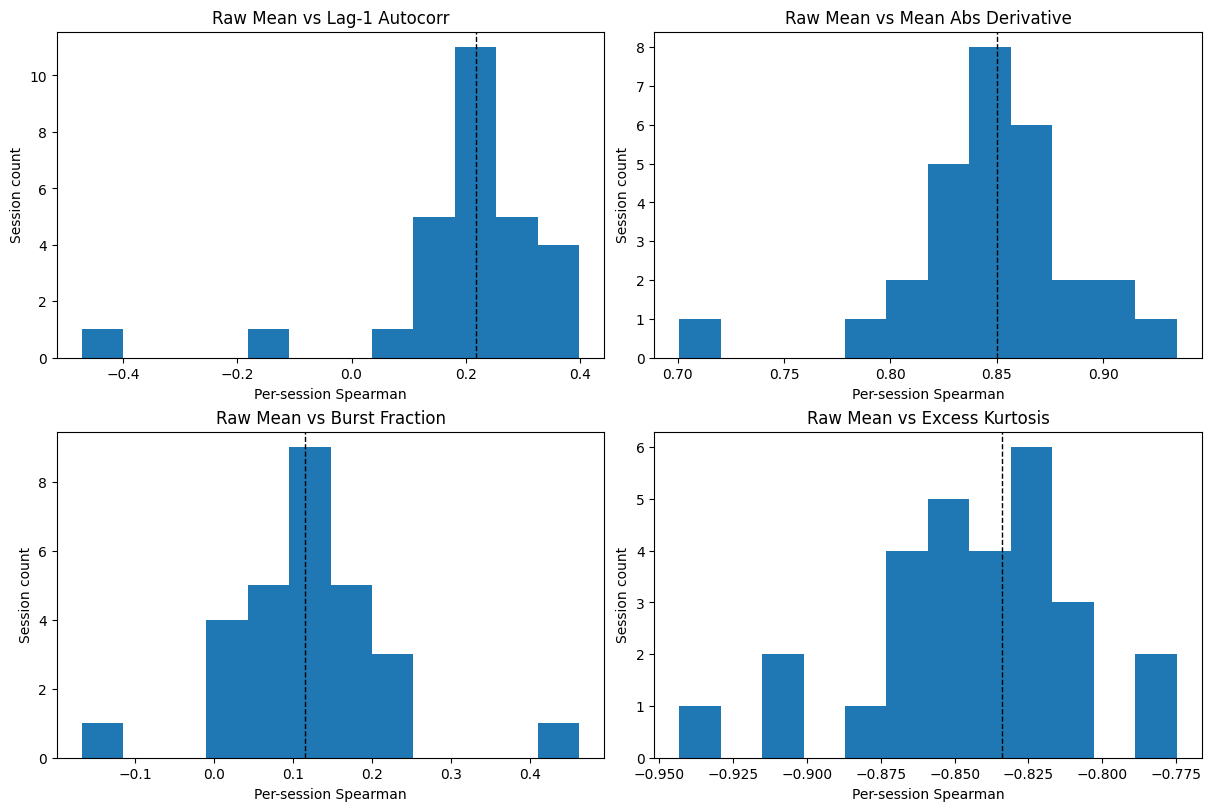

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
plot_specs = [
    ("raw_mean_vs_lag1_autocorr", "Raw Mean vs Lag-1 Autocorr"),
    ("raw_mean_vs_mean_abs_derivative", "Raw Mean vs Mean Abs Derivative"),
    ("raw_mean_vs_burst_fraction", "Raw Mean vs Burst Fraction"),
    ("raw_mean_vs_excess_kurtosis", "Raw Mean vs Excess Kurtosis"),
]

for ax, (col, title) in zip(axes.ravel(), plot_specs):
    vals = session_summary_df[col].to_numpy(dtype=np.float64)
    ax.hist(vals[np.isfinite(vals)], bins=12)
    ax.axvline(np.nanmedian(vals), color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Per-session Spearman")
    ax.set_ylabel("Session count")

plt.show()

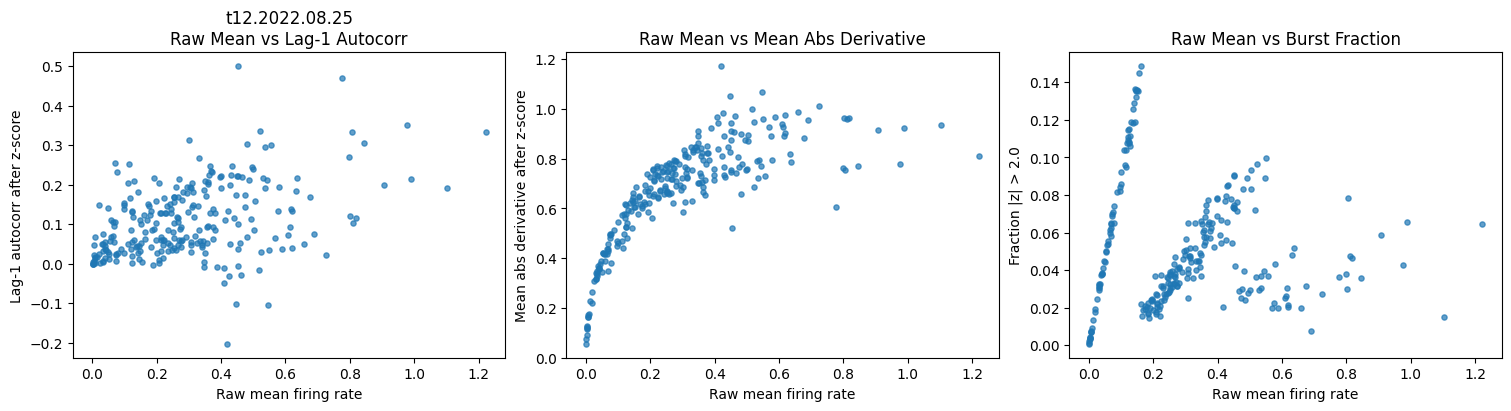

,session_id,channel,n_bins,raw_mean_rate,raw_std,lag1_autocorr,mean_abs_derivative,burst_fraction,excess_kurtosis,valid
7122,t12.2022.08.25,210,183534.0,1.221458,1.322911,0.332423,0.809768,0.064658,2.227378,True
7014,t12.2022.08.25,102,183534.0,1.102700,0.971768,0.190913,0.935541,0.015169,0.276521,True
6999,t12.2022.08.25,87,183534.0,0.989027,0.930672,0.213719,0.924690,0.065694,0.391205,True
7085,t12.2022.08.25,173,183534.0,0.976010,1.198070,0.351414,0.779744,0.042581,3.553563,True
6926,t12.2022.08.25,14,183534.0,0.907123,0.924772,0.200432,0.915038,0.058518,0.547702,True
7167,t12.2022.08.25,255,183534.0,0.844394,1.139762,0.305736,0.768922,0.035628,3.058312,True
7086,t12.2022.08.25,174,183534.0,0.817538,0.888132,0.115593,0.962122,0.046204,1.425309,True
6967,t12.2022.08.25,55,183534.0,0.810596,0.893637,0.102299,0.960476,0.047779,1.206296,True
7119,t12.2022.08.25,207,183534.0,0.805388,1.085828,0.332988,0.756528,0.078590,3.899391,True
7052,t12.2022.08.25,140,183534.0,0.801367,0.792544,0.120705,0.963616,0.030000,2.003003,True


In [7]:
INSPECT_SESSION_ID = session_summary_df.sort_values("raw_mean_vs_lag1_autocorr", ascending=False).iloc[0]["session_id"]
inspect_df = channel_metric_df[channel_metric_df["session_id"] == INSPECT_SESSION_ID].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].scatter(inspect_df["raw_mean_rate"], inspect_df["lag1_autocorr"], s=14, alpha=0.7)
axes[0].set_title(f"{INSPECT_SESSION_ID}\nRaw Mean vs Lag-1 Autocorr")
axes[0].set_xlabel("Raw mean firing rate")
axes[0].set_ylabel("Lag-1 autocorr after z-score")

axes[1].scatter(inspect_df["raw_mean_rate"], inspect_df["mean_abs_derivative"], s=14, alpha=0.7)
axes[1].set_title("Raw Mean vs Mean Abs Derivative")
axes[1].set_xlabel("Raw mean firing rate")
axes[1].set_ylabel("Mean abs derivative after z-score")

axes[2].scatter(inspect_df["raw_mean_rate"], inspect_df["burst_fraction"], s=14, alpha=0.7)
axes[2].set_title("Raw Mean vs Burst Fraction")
axes[2].set_xlabel("Raw mean firing rate")
axes[2].set_ylabel(f"Fraction |z| > {BURST_THRESHOLD}")

plt.show()

inspect_df.sort_values("raw_mean_rate", ascending=False).head(10)